In [1]:
import sys
sys.path.insert(0, "/global/cfs/cdirs/desicollab/users/bautista/bgs/desi_pv_mocks/desi_pv_mocks")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits

from config import load_config 
cfg=load_config('../config_files/mock_config_v3.0.yaml')

cosmo = FlatLambdaCDM(H0=100., Om0=0.31)

In [3]:
print(cfg.data_bgs_clus_data)
print(cfg.data_bgs_clus_rand)

/global/cfs/cdirs/desi/science/td/pv/bgsclustering/Y3/BGS_BRIGHT_clustering_forPV_data.fits
/global/cfs/cdirs/desi/science/td/pv/bgsclustering/Y3/BGS_BRIGHT_clustering_forPV_random.fits


In [4]:
d0_data = fits.open(cfg.data_bgs_clus_data.replace('data.fits', 'data_nolumcut.fits'))[1].data
d0_rand = fits.open(cfg.data_bgs_clus_rand.replace('random.fits', 'random_nolumcut.fits'))[1].data
print(d0_data.names, d0_rand.names, d0_data.size, d0_rand.size)

['RA', 'DEC', 'Z', 'WEIGHT', 'ABSMAG01_SDSS_R'] ['RA', 'DEC', 'Z', 'WEIGHT'] 1135795 80333294


In [6]:
m0_data = h5py.File(cfg.mock_bgs_base_data.format(phase=0, real=0), 'r')
m0_rand = h5py.File(cfg.mock_bgs_base_rand.format(phase=0, real=0), 'r')
print(list(m0_data.keys()))
print(list(m0_rand.keys()))

m0_app_mag = m0_data['app_mag'][...]
m0_zobs = m0_data['zobs'][...]
m0_abs_mag = m0_data['abs_mag'][...]
m0_data.close()
m0_rand.close()

['Y1_COMP', 'Y3_COMP', 'Y5', 'abs_mag', 'app_mag', 'col', 'col_obs', 'dec', 'halo_ind', 'halo_mass', 'is_cen', 'ra', 'vx', 'vy', 'vz', 'zcos', 'zobs']
['Y1_COMP', 'Y3_COMP', 'Y5', 'abs_mag', 'app_mag', 'col', 'col_obs', 'dec', 'halo_mass', 'ra', 'zcos', 'zobs']


Text(0.5, 0, 'Apparent r-band magnitude')

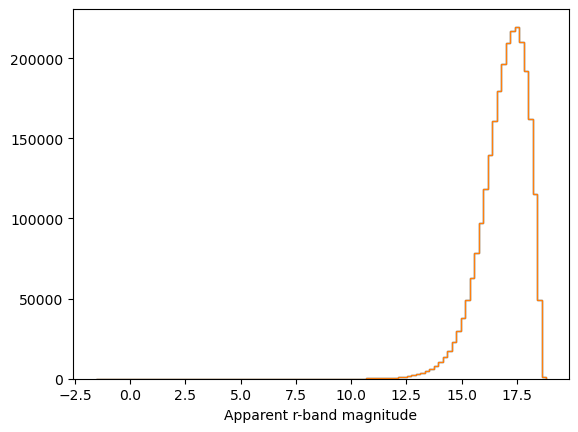

In [14]:
mask = (m0_app_mag < cfg.bgs_clus.appmaglim) & (m0_abs_mag < cfg.bgs_clus.absmaglim) #& (m0_zobs > -0.001)

plt.hist(m0_app_mag, bins=100, histtype='step')
plt.hist(m0_app_mag[mask], bins=100, histtype='step')
plt.xlabel('Apparent r-band magnitude')

Text(0, 0.5, 'Apparent r-band magnitude')

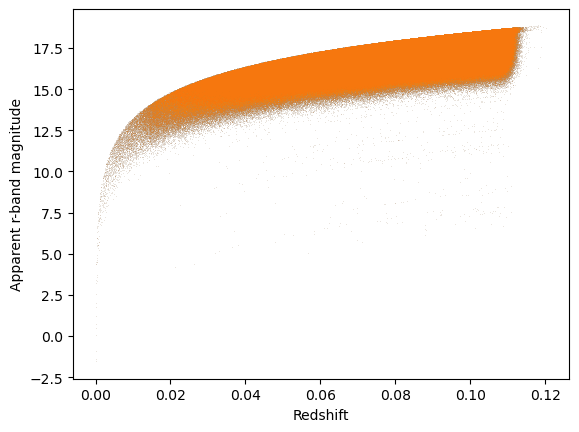

In [12]:

plt.plot(m0_zobs, m0_app_mag, ',', alpha=0.1)
plt.plot(m0_zobs[mask], m0_app_mag[mask], ',', alpha=0.1)
plt.xlabel('Redshift') 
plt.ylabel('Apparent r-band magnitude') 

Text(0, 0.5, 'Absolute r-band magnitude')

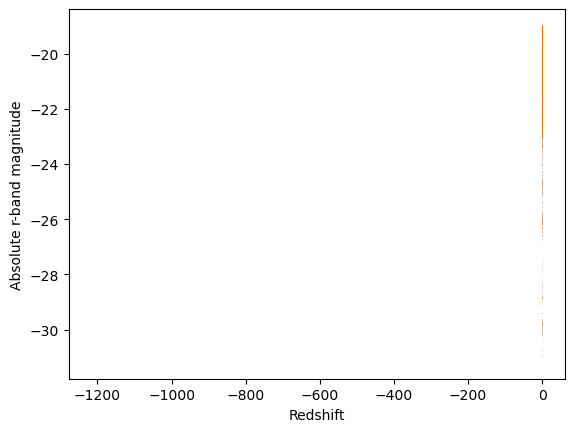

In [13]:
plt.plot(m0_zobs, m0_abs_mag, ',', alpha=0.1)
plt.plot(m0_zobs[mask], m0_abs_mag[mask], ',', alpha=0.1)
plt.xlabel('Redshift') 
plt.ylabel('Absolute r-band magnitude') 

In [37]:
d_data = fits.open(cfg.data_bgs_clus_data.replace('data.fits', 'data_Mr_lt_-19.0.fits'))[1].data
d_rand = fits.open(cfg.data_bgs_clus_rand.replace('random.fits', 'random_Mr_lt_-19.0.fits'))[1].data
#d_data = fits.open(cfg.data_bgs_clus_data)[1].data
#d_rand = fits.open(cfg.data_bgs_clus_rand)[1].data
d_data.names, d_rand.names, d_data.size, d_rand.size

(['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS', 'TARGETID'],
 ['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'],
 393009,
 7860180)

In [17]:
m_data = fits.open(cfg.mock_bgs_clus_data.format(phase=0, real=0))[1].data
m_rand = fits.open(cfg.mock_bgs_clus_rand.format(phase=0))[1].data
m_data.names, m_rand.names, m_data.size, m_rand.size

(['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'],
 ['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'],
 604257,
 15815256)

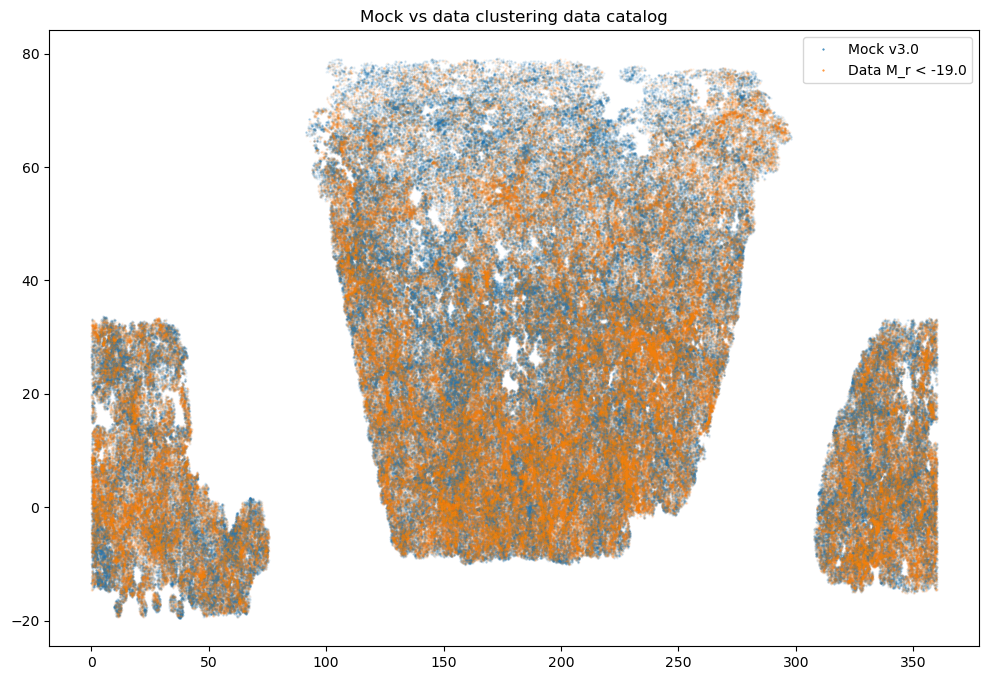

In [20]:
plt.figure(figsize=(12, 8))
plt.plot(m_data['RA'], m_data['DEC'], '.', ms=1, alpha=0.1)
plt.plot(d_data['RA'], d_data['DEC'], '.', ms=1, alpha=0.1)
plt.plot([], [], 'C0.', ms=1, label=f'Mock {cfg.version_bgs_clus}')
plt.plot([], [], 'C1.', ms=1, label=f'Data M_r < -19.0')
plt.title('Mock vs data clustering data catalog')
plt.legend()

Text(0, 0.5, 'Dec [deg]')

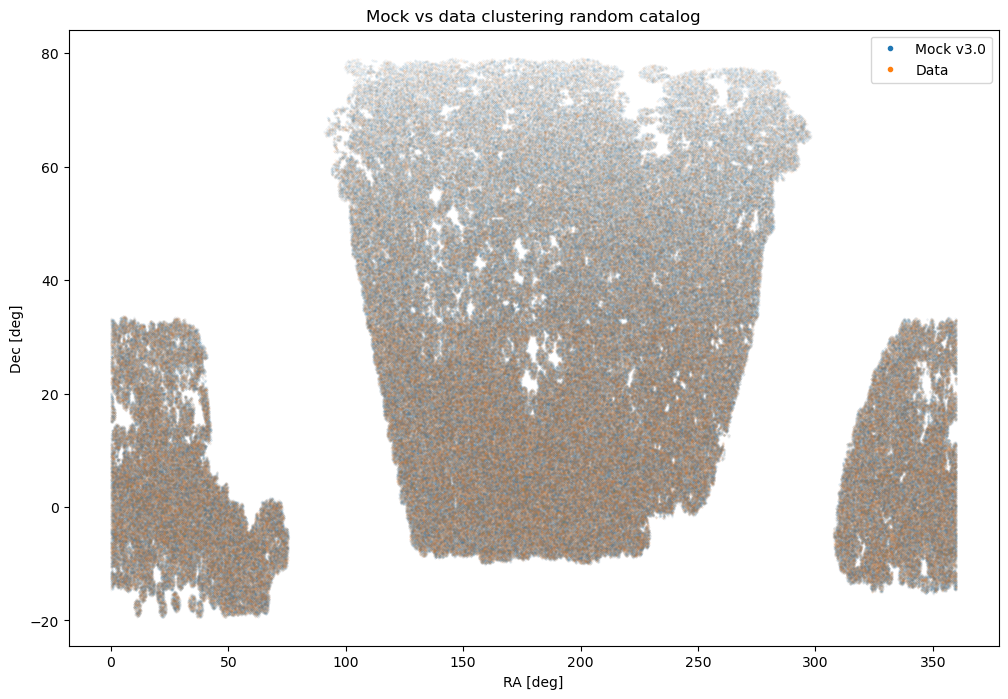

In [22]:
plt.figure(figsize=(12, 8))
plt.plot(m_rand['RA'][::20], m_rand['DEC'][::20], '.', ms=0.5, alpha=0.1)
plt.plot(d_rand['RA'][::20], d_rand['DEC'][::20], '.', ms=0.5, alpha=0.1)
plt.plot([], [], 'C0.', label=f'Mock {cfg.version_bgs_clus}')
plt.plot([], [], 'C1.', label='Data')

plt.title('Mock vs data clustering random catalog')
plt.legend()
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]') 

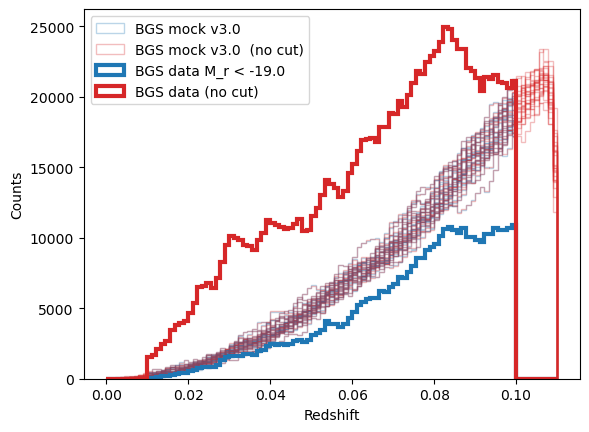

In [25]:
zbins = np.linspace(0, 0.11, 100)

for phase in range(1):
    for real in range(27):
        m0_data_temp = h5py.File(cfg.mock_bgs_base_data.format(phase=phase, real=real), 'r')
        m0_comp = m0_data_temp['Y3_COMP'][...]
        mask = np.random.rand(m0_comp.size) < m0_comp
        m0_z = m0_data_temp['zobs'][...][mask] 

        m_data_temp = fits.open(cfg.mock_bgs_clus_data.format(phase=phase, real=real))[1].data
        m_z = m_data_temp['Z']
        m_label = f'BGS mock {cfg.version_bgs_clus} ' if phase == 0 and real ==0 else None 
        m0_label = f'BGS mock {cfg.version_bgs_base}  (no cut)' if phase == 0 and real ==0 else None 
        
        _=plt.hist(m_z, color='C0', bins=zbins, histtype='step', alpha=0.3, label=m_label)
        _=plt.hist(m0_z, color='C3', bins=zbins, histtype='step', alpha=0.3, label=m0_label)

_=plt.hist(d_data['Z'], bins=zbins, histtype='step', color='C0', lw=3, label='BGS data M_r < -19.0')
_=plt.hist(d0_data['Z'], bins=zbins, histtype='step', color='C3', lw=3, label='BGS data (no cut)')

plt.ylabel('Counts') 
plt.xlabel('Redshift')
plt.legend()
plt.savefig(f'../plots/Nz_bgs_base_clustering_data_vs_mock_{cfg.version_bgs_clus}.pdf')

In [26]:
area_ngc = 8500.3589 # sq deg
area_sgc = 3610.6785 # sq deg
area_tot = area_ngc+area_sgc 

zbins = np.linspace(0, 0.11, 100)
zcen = 0.5*(zbins[:-1]+zbins[1:]) 
zvol = (cosmo.comoving_volume(zbins[1:]).value-cosmo.comoving_volume(zbins[:-1]).value)*(1/(4.*np.pi*((180./np.pi)**2)))

def get_nz(z, weights=None,  area=area_tot):
    nz, _ = np.histogram(z, bins=zbins, weights=weights)
    return nz/zvol/area


In [27]:
m_nzs = []
for phase in range(1):
    for real in range(cfg.n_reals):
        m_data_temp = fits.open(cfg.mock_bgs_clus_data.format(phase=phase, real=real))[1].data
        m_nz = get_nz(m_data_temp['Z'], area=area_tot)
        #print(phase, real, len(m_data_temp))
        m_nzs.append(m_nz)
m_nzs = np.array(m_nzs) 
print(m_nzs.shape)

(27, 99)


In [29]:
m0_nzs = []
for phase in range(1):
    for real in range(cfg.n_reals):
        m0_data_temp = h5py.File(cfg.mock_bgs_base_data.format(phase=phase, real=real), 'r')
        m0_app_mag = m0_data_temp['app_mag'][...]
        m0_zobs = m0_data_temp['zobs'][...]
        m0_abs_mag = m0_data_temp['abs_mag'][...]
        m0_comp = m0_data_temp['Y3_COMP'][...]
        m0_data_temp.close()
        
        mask = (
                (m0_app_mag < cfg.bgs_clus.appmaglim) & 
                (m0_abs_mag < cfg.bgs_clus.absmaglim) & 
                (m0_comp > np.random.rand(m0_comp.size)) & 
                (m0_zobs > cfg.bgs_clus.zmin) & 
                (m0_zobs < cfg.bgs_clus.zmax)
                )
        #print(phase, real, mask.size, np.sum(mask))

        m0_nz = get_nz(m0_zobs[mask], area=area_tot)
        m0_nzs.append(m0_nz)
m0_nzs = np.array(m0_nzs) 


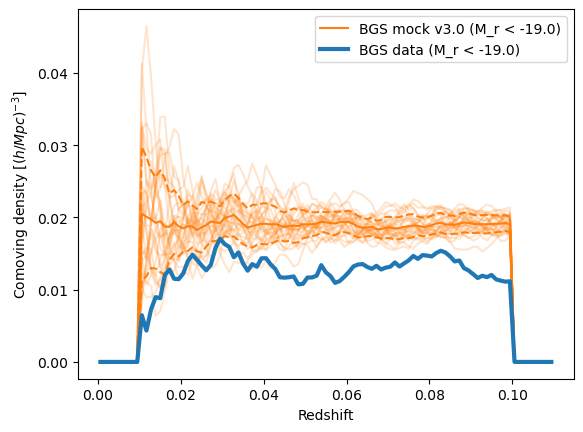

In [38]:
for m_nz in m0_nzs:      
    plt.plot(zcen, m_nz, 'C1-', alpha=0.2)
plt.plot(zcen, np.mean(m0_nzs, axis=0), 'C1-', label=f"BGS mock {cfg.version_bgs_clus} (M_r < {cfg.bgs_clus.absmaglim})") 
plt.plot(zcen, np.mean(m0_nzs, axis=0)+np.std(m0_nzs, axis=0), 'C1--') 
plt.plot(zcen, np.mean(m0_nzs, axis=0)-np.std(m0_nzs, axis=0), 'C1--') 

d_nz = get_nz(d_data['Z'], weights=d_data['WEIGHT'], area=area_tot)
#d_nz = get_nz(d_data['Z'], area=area)

plt.plot(zcen, d_nz, 'C0-', lw=3, label='BGS data (M_r < -19.0)')
#plt.plot(zcen, d_nz, 'C0-', lw=3, label='BGS data (M_r < -17.7)')
#plt.plot(d_data['Z'], d_data['NDENS'], 'C0,')

plt.ylabel('Comoving density [${(h/Mpc)}^{-3}$]')
plt.xlabel('Redshift')
plt.legend()
#plt.ylim(0, 0.01)
plt.savefig(f"../plots/nz_bgs_clustering_data_Mr_lt_-19.0_vs_mock_{cfg.version_bgs_clus}.pdf")